# Example - Selecting FRET populations

This notebook replicates the selecting FRET populations notebooks of FRETBursts in PhotonBursts.

> Old text in insets

> `Old code in # comments`
>
> `With equivalent new code below`

> *This notebook is part of smFRET burst analysis software [FRETBursts](http://opensmfs.github.io/FRETBursts/).*
> 
> In this notebook shows two methods to select FRET populations: size filtering and DCBS.
> For a complete tutorial on burst analysis see 
> [FRETBursts - us-ALEX smFRET burst analysis](FRETBursts - us-ALEX smFRET burst analysis.ipynb).


This notebook shows how to select and plot data.

The first step is to import PhotonBursts, we will also import some common libraries.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# from fretbursts import * # prefer explicit import
import fretbursts as frb 

--------------------------------------------------------------
 You are running FRETBursts (version 1.0.1).

 If you use this software please cite the following paper:

   FRETBursts: An Open Source Toolkit for Analysis of Freely-Diffusing Single-Molecule FRET
   Ingargiola et al. (2016). http://dx.doi.org/10.1371/journal.pone.0160716 

--------------------------------------------------------------


# Get and process data

Enter the name of your file between the quotes after `full_fname = `

Then we will load the relevant data

In [2]:
full_fname = "HP3_TE300_SPC630.hdf5"

# d = loader.photon_hdf5(full_fname)
raw = frb.photonHDF5.load(full_fname)

# loader.alex_apply_period(d)
data = frb.photonHDF5.regularize_dets(raw)

And finally start to define analysis parameters

In [3]:
frb.fretfactory.ALEXdefaults.plot_kwargs

({'color': '#0055d4'},
 {'color': '#2ca02c'},
 {'color': '#e74c3c'},
 {'color': '#9b59b6'})

([<matplotlib.collections.PathCollection at 0x7069931f0ef0>,
 [[<matplotlib.lines.Line2D at 0x70699319cf50>],
 Text(0.5, 0, 'Interphoton delays $(ms)$'),
 Text(0, 0.5, '# Delays'),
 <matplotlib.legend.Legend at 0x706993162d20>)

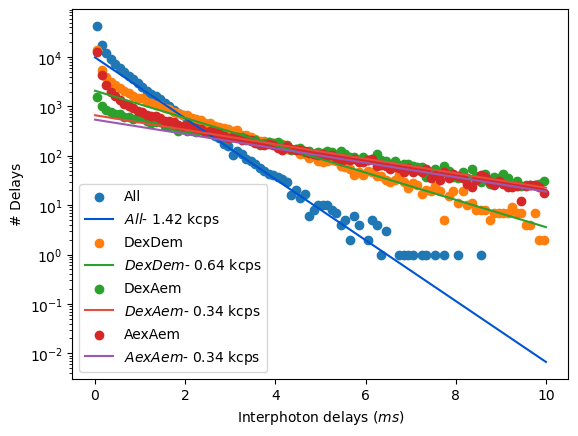

In [4]:
# d.calc_bg(bg.exp_fit, time_s=1000, tail_min_us=(800, 4000, 1500, 1000, 3000))
bg = frb.fretfactory.make_bg(data, period=60.0, tail_min=500e-6, func=frb.bg.exp_mlefit, auto_threshold=True)

frb.plot.hist_interphoton(data, bg['bg'], 0, streams=frb.fretfactory.ALEXdefaults.streams, labels=frb.fretfactory.ALEXdefaults.labels, fit_streams_kwargs=frb.fretfactory.ALEXdefaults.plot_kwargs)

In [5]:
frb.fretfactory.ALEXdefaults.labels

('All', 'DexDem', 'DexAem', 'AexAem')

In [6]:
# d.burst_search(m=10, F=6.0)
acbs = frb.fretfactory.make_burst_search(bg['bg'], m=10, F=6.0, streams=frb.PhSel('0ex_1ex1em'))

# ds = d.select_bursts(select_bursts.size, add_naa=True, th1=40)
ac_gAll = frb.make_geq_gate(acbs['NphAll_bg'], 40.0)

# Filtering method

We can select the FRET population (S ~ 0.5) combining these two filters:

1. Filter out A-only: select bursts with counts during $D_{ex}$ > threshold
2. Filter out D-only: select bursts with counts in $A_{ex}A_{em}$ > threshold

In code, this becomes:

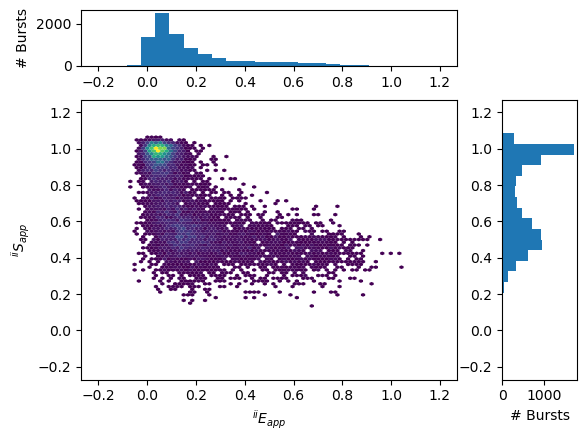

In [7]:
# ds_no_Aonly = ds.select_bursts(select_bursts.size, th1=30)
ac_gDactive = ac_gAll & frb.make_geq_gate(acbs['NphDex_bg'], 30.0)


# alex_jointplot(ds)
frb.plot.jointplot(data, acbs['E_bg'], acbs['S_bg'], gate=ac_gDactive, cfunc=frb.plot.hexbin, 
                   cplot_kwargs={'gridsize':80, 'extent':(-0.2,1.2,-0.2,1.2), 
                                 'mincnt':1, 'edgecolor':'none', 'linewidth':0.2},
                   hplot_kwargs={'bins':np.linspace(-0.2,1.2, 25)});

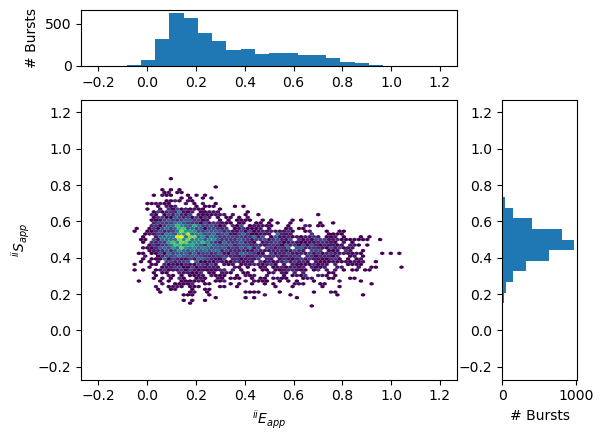

In [8]:
# ds_fret = ds_no_Aonly.select_bursts(select_bursts.naa, th1=30)
ac_gFRET = ac_gDactive & frb.make_geq_gate(acbs['NphAA_bg'], 30)

# alex_jointplot(ds_fret)
frb.plot.jointplot(data, acbs['E_bg'], acbs['S_bg'], gate=ac_gFRET, cfunc=frb.plot.hexbin, 
                   cplot_kwargs={'gridsize':80, 'extent':(-0.2,1.2,-0.2,1.2), 
                                 'mincnt':1, 'edgecolor':'none', 'linewidth':0.2},
                   hplot_kwargs={'bins':np.linspace(-0.2,1.2, 25)});

## DCBS Method

With Dual-channel Burst Search (DCBS),
we define bursts as the intersection of a burst search performed on $D_{ex}$ stream and 
one performed on $A_{ex}A_{em}$ stream (see ([Nir et al. JPC 2006](doi.org/10.1021/jp063483n))).

In this way we filter D-only and A-only bursts,
but also we reduce the burst duration of FRET bursts to the portion where
$D_{ex}$ and $A_{ex}A_{em}$ both give signal. This property allows filtering 
acceptor photo-blinking, that causes part of a burst to appear as D-only.

To perform DCBS in FRETBursts we use:

In [9]:
# d_fret_2 = bext.burst_search_and_gate(d)
dcbs1 = frb.fretfactory.make_burst_search(bg['bg'], m=10, F=6.0, streams=(frb.PhSel('0ex'), frb.PhSel('1ex1em')))

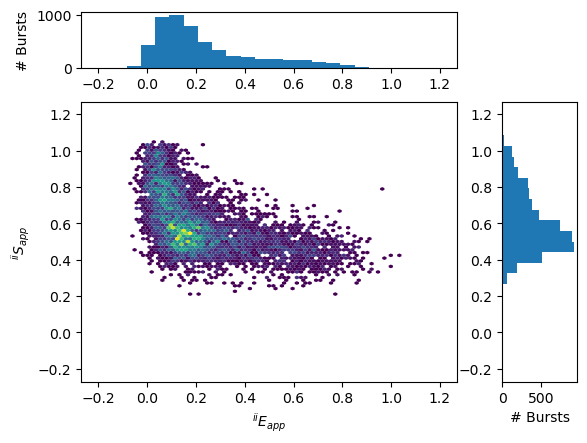

In [10]:
# ds_fret_2 = d_fret_2.select_bursts(select_bursts.size, th1=30)
d1_gFRET = frb.make_geq_gate(dcbs1['NphDex_bg'], 30)

# alex_jointplot(ds_fret_2);
frb.plot.jointplot(data, dcbs1['E_bg'], dcbs1['S_bg'], gate=d1_gFRET, cfunc=frb.plot.hexbin, 
                   cplot_kwargs={'gridsize':80, 'extent':(-0.2,1.2,-0.2,1.2), 
                                 'mincnt':1, 'edgecolor':'none', 'linewidth':0.2},
                   hplot_kwargs={'bins':np.linspace(-0.2,1.2, 25)});

The function [bext.burst_search_and_gate()](http://fretbursts.readthedocs.io/en/latest/plugins.html?highlight=burst_search_and#fretbursts.burstlib_ext.burst_search_and_gate)
performs two burst searches on the photon streams defined by `ph_sel1` and `ph_sel2` arguments
(by default `ph_sel1=Ph_sel(Dex='DAem')` and `ph_sel2=Ph_sel(Aex='Aem')`, i.e. $D_{ex}$ and $A_{ex}A_{em}$).
Then, it takes the "intersection in time" (and-gate) for the two sets of bursts.


`burst_search_and_gate` accepts the same 
*m*, *F*, and *min_rate_cps* arguments as [Data.burst_search()](http://fretbursts.readthedocs.io/en/latest/data_class.html#fretbursts.burstlib.Data.burst_search).
It is also possible to use different burst search parameters for the two
burst searches:

In [11]:
# d_fret_22 = bext.burst_search_and_gate(d, m=(8, 10), F=(5, 12))
dcbs2 = frb.fretfactory.make_burst_search(bg['bg'], m=(8, 10), F=(5.0, 12.0), streams=(frb.PhSel('0ex'), frb.PhSel('1ex1em')))

Before plotting we still need to select bursts by size:

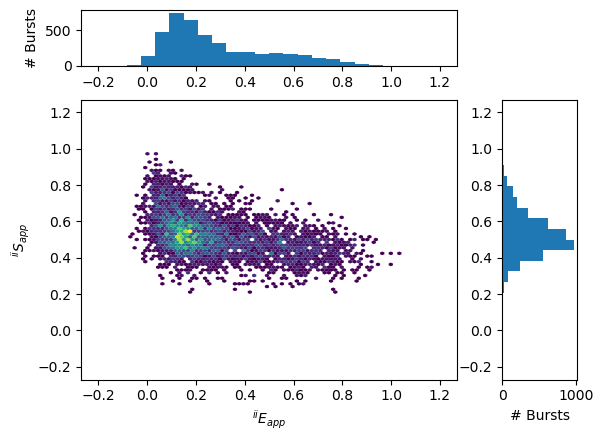

In [12]:
# ds_fret_22 = d_fret_22.select_bursts(select_bursts.size, th1=30)
d2_gFRET = frb.make_geq_gate(dcbs2['NphDex_bg'], 30)

# alex_jointplot(ds_fret_22);
frb.plot.jointplot(data, dcbs2['E_bg'], dcbs2['S_bg'], gate=d2_gFRET, cfunc=frb.plot.hexbin, 
                   cplot_kwargs={'gridsize':80, 'extent':(-0.2,1.2,-0.2,1.2), 
                                 'mincnt':1, 'edgecolor':'none', 'linewidth':0.2},
                   hplot_kwargs={'bins':np.linspace(-0.2,1.2, 25)});